In [21]:
pip install xarray

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install toolz

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install netcdf4

Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install h5netcdf 

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install cftime

Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install cfgrib

Note: you may need to restart the kernel to use updated packages.


In [28]:
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import cftime
from scipy import stats

In [29]:
def lineplot_setup(xmin, xmax, xlab, ylab, ymin=None, ymax=None, title=None, ax=None):
    if ax is None:
        ax = plt.gca()  # Usa el eje actual si no se pasa uno

    ax.set_xlim([xmin, xmax])
    if ymin is not None and ymax is not None:
        ax.set_ylim([ymin, ymax])
    
    ax.grid(linestyle='--', alpha=0.66)
    ax.minorticks_on()
    
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xlabel(xlab, fontsize=13)
    ax.set_ylabel(ylab, fontsize=13)
    ax.set_title(title, fontsize=15)


### **<font color="Purple"> Datos de ERA5 </font>**

### **<font color="olive"> Temperatura </font>**

In [30]:
filet2m_era5 = 'datasetsok/anomT_4x4_E5.nc'

In [31]:
t2m = xr.open_dataset(filet2m_era5)
t2m 

<xarray.Dataset> Size: 672kB
Dimensions:    (time: 16802)
Coordinates:
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
    number     (time) int64 134kB ...
    surface    (time) float64 134kB ...
    dayofyear  (time) int64 134kB ...
Data variables:
    t2m        (time) float64 134kB ...

### **<font color="olive"> Viento </font>**

In [32]:
fileU_era5 = 'datasetsok/anomV_4x4_E5.nc'

In [33]:
ue5 = xr.open_dataset(fileU_era5 )
ue5

<xarray.Dataset> Size: 538kB
Dimensions:         (time: 16802)
Coordinates:
  * time            (time) datetime64[ns] 134kB 1979-01-01 ... 2024-12-31
    pressure_level  (time) float64 134kB ...
    dayofyear       (time) int64 134kB ...
Data variables:
    u               (time) float64 134kB ...

### **<font color="Purple"> Datos de HadGEM3</font>**

### **<font color="olive"> Temperatura </font>**

In [34]:
filetas_hg = 'datasetsok/anomT_4x4_HG.nc'

In [35]:
tas = xr.open_dataset(filetas_hg)
tas

<xarray.Dataset> Size: 415kB
Dimensions:    (time: 12960)
Coordinates:
  * time       (time) object 104kB 1979-01-01 00:00:00 ... 2014-12-30 00:00:00
    height     (time) float64 104kB ...
    dayofyear  (time) int64 104kB ...
Data variables:
    tas        (time) float64 104kB ...

### **<font color="olive"> Viento </font>**

In [36]:
fileU_hg = 'datasetsok/anomV_4x4_HG.nc'

In [37]:
uhg = xr.open_dataset(fileU_hg)
uhg

<xarray.Dataset> Size: 415kB
Dimensions:    (time: 12960)
Coordinates:
  * time       (time) object 104kB 1979-01-01 12:00:00 ... 2014-12-30 12:00:00
    plev       (time) float64 104kB ...
    dayofyear  (time) int64 104kB ...
Data variables:
    ua         (time) float64 104kB ...

In [38]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Extraer las variables (ajusta los nombres si es necesario)
tas_data = tas["tas"]
uhg_data = uhg["ua"]

# Alinear por coordenadas comunes
tas_data, uhg_data = xr.align(tas_data, uhg_data, join='inner')

# Aplanar y limpiar NaNs
tas_flat = tas_data.values.flatten()
uhg_flat = uhg_data.values.flatten()
mask = ~np.isnan(tas_flat) & ~np.isnan(uhg_flat)
tas_clean = tas_flat[mask]
uhg_clean = uhg_flat[mask]

# Calcular el coeficiente de correlación de Pearson
r, p_value = pearsonr(tas_clean, uhg_clean)

# Gráfico de dispersión
plt.figure(figsize=(7,5))
plt.scatter(tas_clean, uhg_clean, s=5, alpha=0.5, color="steelblue")
plt.xlabel("Temperatura (tas)")
plt.ylabel("uhg")
plt.title(f"Dispersión tas vs uhg\nCoeficiente de correlación R = {r:.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: `x` and `y` must have length at least 2.

Coeficiente de correlación R = -0.2482
Valor p = 2.356496e-234


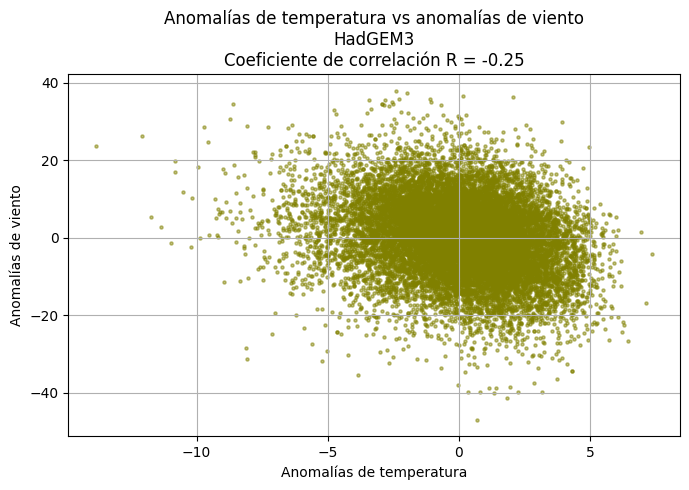

In [20]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

tas_data = t2m["t2m"]
uhg_data = ue5["u"]

# Alinear por coordenadas comunes
tas_data, uhg_data = xr.align(tas_data, uhg_data, join='inner')

# Aplanar y limpiar NaNs
tas_flat = tas_data.values.flatten()
uhg_flat = uhg_data.values.flatten()
mask = ~np.isnan(tas_flat) & ~np.isnan(uhg_flat)
tas_clean = tas_flat[mask]
uhg_clean = uhg_flat[mask]

# Calcular el coeficiente de correlación de Pearson
r, p_value = pearsonr(tas_clean, uhg_clean)

# Imprimir p-valor
print(f"Coeficiente de correlación R = {r:.4f}")
print(f"Valor p = {p_value:.6e}")  

# Gráfico de dispersión
plt.figure(figsize=(7,5))
plt.scatter(tas_clean, uhg_clean, s=5, alpha=0.5, color="OLIVE")
plt.xlabel("Anomalías de temperatura")
plt.ylabel("Anomalías de viento")
plt.title(f"Anomalías de temperatura vs anomalías de viento\nHadGEM3\nCoeficiente de correlación R = {r:.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
tas_data = tas["tas"]
ua_data = uhg["ua"]

In [20]:
t2m_data = t2m["t2m"]
u_data = ue5["u"]

In [28]:
res = stats.linregress(t2m_data, u_data)
print(f"R-squared: {res.rvalue**2:.6f}")

R-squared: 0.061621


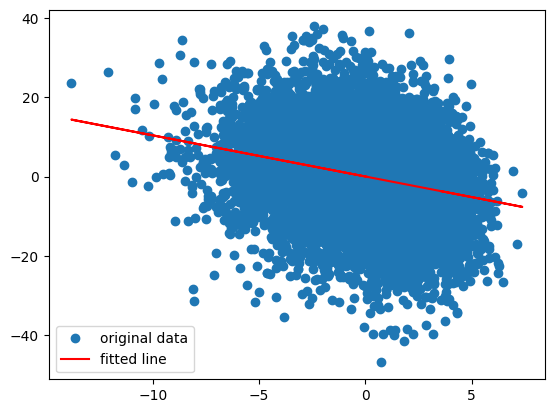

In [29]:
plt.plot(t2m_data, u_data, 'o', label='original data')
plt.plot(t2m_data, res.intercept + res.slope*t2m_data, 'r', label='fitted line')
plt.legend()
plt.show()

In [30]:
# Two-sided inverse Students t-distribution
# p - probability, df - degrees of freedom
from scipy.stats import t
tinv = lambda p, df: abs(t.ppf(p/2, df))

In [31]:
ts = tinv(0.05, len(t2m_data))
print(f"slope (95%): {res.slope:.6f} +/- {ts*res.stderr:.6f}")
print(f"intercept (95%): {res.intercept:.6f}"
      f" +/- {ts*res.intercept_stderr:.6f}")

slope (95%): -1.038607 +/- 0.061292
intercept (95%): 0.003322 +/- 0.141443
